<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/set5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ CatBoost not installed (optional baseline)
✔ Environment ready

================ STEP 1: DATA LOADING ================
train.csv → (160000, 2)
labels
1    80000
0    80000
Name: count, dtype: int64
test.csv → (160000, 2)
labels
1    80000
0    80000
Name: count, dtype: int64
phiusiil.csv → (235795, 2)
labels
1    134850
0    100945
Name: count, dtype: int64

================ STEP 2: LABEL DISTRIBUTION ================


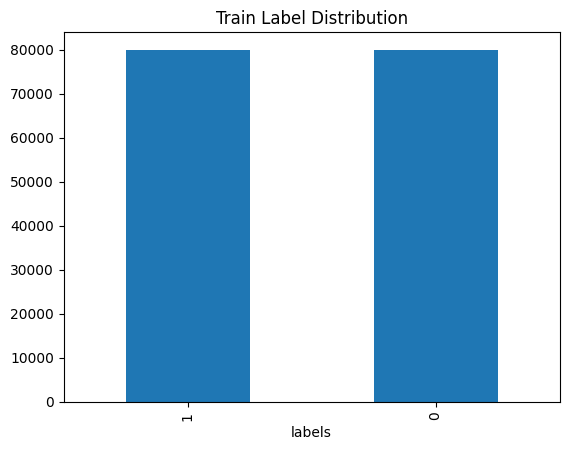

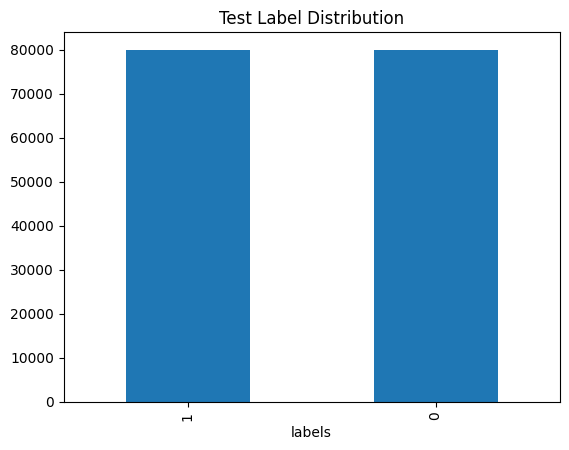

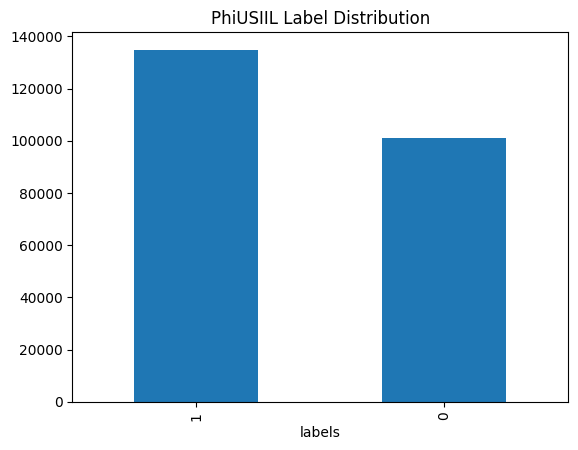


================ STEP 3: LEXICAL FEATURES ================

================ STEP 4: CHAR N-GRAM TF-IDF ================

================ STEP 5: FEATURE FUSION ================

================ STEP 6: ONLINE ML (FTRL STYLE) ================

================ STEP 7: ANOMALY DETECTION ================


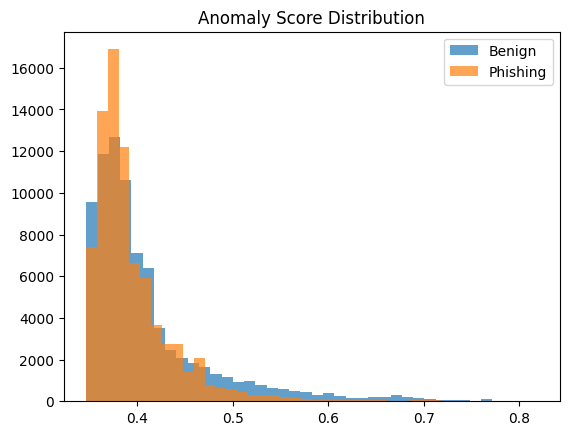


================ STEP 8: TINY TCN + ATTENTION ================
Epoch 1 Loss: 436.50218980014324
Epoch 2 Loss: 316.01437497138977
Epoch 3 Loss: 278.41425881534815

================ STEP 9: SCORE FUSION ================

================ STEP 10: EVALUATION ================

TEST SET
Accuracy: 0.82046875  Precision: 0.9600882938822389  Recall: 0.6687375  F1: 0.7883556950553702
PR-AUC: 0.9601073541312413  FPR: 0.0278

PHIUSIIL (ZERO-DAY)
Accuracy: 0.8320617485527683  Precision: 0.7735981294988826  Recall: 0.9985984427141268  F1: 0.8718151242550685
PR-AUC: 0.9319421669756894  FPR: 0.3904106196443608

================ STEP 11: COMPUTATIONAL EFFICIENCY ================
ML time/url: 4.836320877075195e-06
DL time/url: 0.009772539138793945
Tiny TCN params: 18626

================ STEP 12: CONCEPT DRIFT (PAGE–HINKLEY) ================
⚠️ Drift detected at 54852


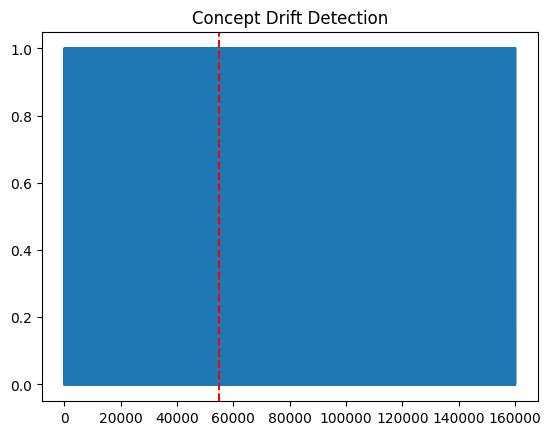


================ STEP 13: BASELINE MODELS ================
RF Accuracy: 1.0  RF F1: 1.0

================ STEP 14: COMPARISON TABLE ================
             Model  Accuracy  F1-score
0    Random Forest  1.000000  1.000000
1    CatBoost (NA)       NaN       NaN
2  Proposed Hybrid  0.820469  0.788356

================ PIPELINE COMPLETED SUCCESSFULLY ================


In [1]:
# ==========================================================
# ONE-CELL FULL HYBRID PHISHING URL DETECTION SYSTEM
# (COMPLETE PPT COVERAGE)
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc, confusion_matrix
)
from scipy.sparse import hstack

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except:
    CATBOOST_AVAILABLE = False
    print("⚠️ CatBoost not installed (optional baseline)")

print("✔ Environment ready")

# ==========================================================
print("\n================ STEP 1: DATA LOADING ================")

BASE = "/content/drive/MyDrive/data"
TRAIN = os.path.join(BASE, "train.csv")
TEST  = os.path.join(BASE, "test.csv")
PHI   = os.path.join(BASE, "phiusiil.csv")

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL":"url","label":"labels"})
    df = df[["url","labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    print(f"{os.path.basename(path)} → {df.shape}")
    print(df.labels.value_counts())
    return df

train_df = load_data(TRAIN)
test_df  = load_data(TEST)
phi_df   = load_data(PHI)

# ==========================================================
print("\n================ STEP 2: LABEL DISTRIBUTION ================")

for name, df in [("Train",train_df),("Test",test_df),("PhiUSIIL",phi_df)]:
    plt.figure()
    df.labels.value_counts().plot(kind="bar")
    plt.title(f"{name} Label Distribution")
    plt.show()

# ==========================================================
print("\n================ STEP 3: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'),
        url.count('-'),
        url.count('%'),
        url.count('@'),
        math.log2(len(url)+1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

# ==========================================================
print("\n================ STEP 4: CHAR N-GRAM TF-IDF ================")

tfidf = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=2)
X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

# ==========================================================
print("\n================ STEP 5: FEATURE FUSION ================")

# FIXED: Added .tocsr() to allow for slicing and faster row-access later
X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_test_ml  = hstack([X_ng_test, X_lex_test]).tocsr()
X_phi_ml   = hstack([X_ng_phi, X_lex_phi]).tocsr()

y_train, y_test, y_phi = train_df.labels, test_df.labels, phi_df.labels

# ==========================================================
print("\n================ STEP 6: ONLINE ML (FTRL STYLE) ================")

clf = SGDClassifier(loss="log_loss")
clf.fit(X_train_ml, y_train)

p_ml_test = clf.predict_proba(X_test_ml)[:,1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:,1]

# ==========================================================
print("\n================ STEP 7: ANOMALY DETECTION ================")

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_lex_train[y_train==0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

plt.hist(a_test[y_test==0], bins=40, alpha=0.7, label="Benign")
plt.hist(a_test[y_test==1], bins=40, alpha=0.7, label="Phishing")
plt.legend(); plt.title("Anomaly Score Distribution"); plt.show()

# ==========================================================
print("\n================ STEP 8: TINY TCN + ATTENTION ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url)))
char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"] = 0

def encode(u):
    s=[char2idx.get(c,0) for c in u[:MAX_LEN]]
    return s+[0]*(MAX_LEN-len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X=[encode(u) for u in urls]
        self.y=y.values
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i],dtype=torch.float)

train_dl=DataLoader(URLDS(train_df.url,y_train),128,shuffle=True)
test_dl =DataLoader(URLDS(test_df.url,y_test),128)
phi_dl  =DataLoader(URLDS(phi_df.url,y_phi),128)

class TinyTCNAttn(nn.Module):
    def __init__(self,v):
        super().__init__()
        self.emb=nn.Embedding(v,64,padding_idx=0)
        self.conv=nn.Conv1d(64,64,3,padding=1)
        self.attn=nn.Linear(64,1)
        self.fc=nn.Linear(64,1)
    def forward(self,x):
        x=self.emb(x).transpose(1,2)
        x=torch.relu(self.conv(x)).transpose(1,2)
        w=torch.softmax(self.attn(x).squeeze(-1),1)
        return self.fc((x*w.unsqueeze(-1)).sum(1)).squeeze()

model=TinyTCNAttn(len(char2idx))
opt=torch.optim.Adam(model.parameters(),lr=0.001)
lossf=nn.BCEWithLogitsLoss()

for e in range(3):
    total=0
    for X,y in train_dl:
        opt.zero_grad()
        l=lossf(model(X),y)
        l.backward()
        opt.step()
        total+=l.item()
    print(f"Epoch {e+1} Loss:",total)

def dl_scores(dl):
    model.eval()
    s=[]
    with torch.no_grad():
        for X,_ in dl:
            s.extend(torch.sigmoid(model(X)).numpy())
    return np.array(s)

p_dl_test = dl_scores(test_dl)
p_dl_phi  = dl_scores(phi_dl)

# ==========================================================
print("\n================ STEP 9: SCORE FUSION ================")

α=0.6
S_test = α*p_ml_test + (1-α)*p_dl_test*(1-a_test/np.max(a_test))
S_phi  = α*p_ml_phi  + (1-α)*p_dl_phi *(1-a_phi/np.max(a_phi))

yhat_test = (S_test>0.5).astype(int)
yhat_phi  = (S_phi>0.5).astype(int)

# ==========================================================
print("\n================ STEP 10: EVALUATION ================")

def evaluate(y,yh,s,name):
    acc=accuracy_score(y,yh)
    prec=precision_score(y,yh)
    rec=recall_score(y,yh)
    f1=f1_score(y,yh)
    p,r,_=precision_recall_curve(y,s)
    pr_auc=auc(r,p)
    cm=confusion_matrix(y,yh)
    TN,FP,FN,TP=cm.ravel()
    fpr=FP/(FP+TN)
    print(f"\n{name}")
    print("Accuracy:",acc," Precision:",prec," Recall:",rec," F1:",f1)
    print("PR-AUC:",pr_auc," FPR:",fpr)

evaluate(y_test,yhat_test,S_test,"TEST SET")
evaluate(y_phi,yhat_phi,S_phi,"PHIUSIIL (ZERO-DAY)")

# ==========================================================
print("\n================ STEP 11: COMPUTATIONAL EFFICIENCY ================")

# FIXED: Slicing works now because X_test_ml was converted to CSR in Step 5
start=time.time()
clf.predict_proba(X_test_ml[:1000])
ml_time=(time.time()-start)/1000

sample=torch.tensor([encode(test_df.url.iloc[0])])
start=time.time(); model(sample); dl_time=time.time()-start
params=sum(p.numel() for p in model.parameters())

print("ML time/url:",ml_time)
print("DL time/url:",dl_time)
print("Tiny TCN params:",params)

# ==========================================================
print("\n================ STEP 12: CONCEPT DRIFT (PAGE–HINKLEY) ================")

class PageHinkley:
    def __init__(self,delta=0.005,lam=50):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.mean=0; self.sum=0; self.min=0; self.t=0
    def update(self,x):
        self.t+=1
        self.mean+=(x-self.mean)/self.t
        self.sum+=x-self.mean-self.delta
        self.min=min(self.min,self.sum)
        if self.sum-self.min>self.lam:
            self.reset(); return True
        return False

ph=PageHinkley()
losses=[]; drifts=[]
for i in range(len(test_df)):
    loss=int(yhat_test[i]!=y_test.iloc[i])
    losses.append(loss)
    if ph.update(loss):
        drifts.append(i)
        print("⚠️ Drift detected at",i)

plt.plot(losses)
for d in drifts: plt.axvline(d,color="red",linestyle="--")
plt.title("Concept Drift Detection"); plt.show()

# ==========================================================
print("\n================ STEP 13: BASELINE MODELS ================")

rf=RandomForestClassifier(n_estimators=200,n_jobs=-1,random_state=42)
rf.fit(X_ng_train,y_train)
rf_pred=rf.predict(X_ng_test)
rf_acc=accuracy_score(y_test,rf_pred)
rf_f1=f1_score(y_test,rf_pred)

print("RF Accuracy:",rf_acc," RF F1:",rf_f1)

if CATBOOST_AVAILABLE:
    cb=CatBoostClassifier(iterations=300,depth=6,verbose=False)
    cb.fit(X_ng_train,y_train)
    cb_pred=cb.predict(X_ng_test)
    cb_acc=accuracy_score(y_test,cb_pred)
    cb_f1=f1_score(y_test,cb_pred)
    print("CB Accuracy:",cb_acc," CB F1:",cb_f1)

# ==========================================================
print("\n================ STEP 14: COMPARISON TABLE ================")

results=pd.DataFrame({
    "Model":["Random Forest","CatBoost" if CATBOOST_AVAILABLE else "CatBoost (NA)","Proposed Hybrid"],
    "Accuracy":[rf_acc,cb_acc if CATBOOST_AVAILABLE else None,accuracy_score(y_test,yhat_test)],
    "F1-score":[rf_f1,cb_f1 if CATBOOST_AVAILABLE else None,f1_score(y_test,yhat_test)]
})
print(results)

print("\n================ PIPELINE COMPLETED SUCCESSFULLY ================")